# Explainable Customer Churn Prediction

## 1. Explainable AI with SHAP

This notebook focuses on interpreting the predictions of the
Logistic Regression model using SHAP (SHapley Additive exPlanations).
The goal is to understand which features contribute to customer
churn predictions at both the global and individual levels.

In [23]:
!pip install shap

In [24]:
import shap

In [25]:
print(shap.__version__)

0.52.0


In [26]:
import pickle


with open("/content/x_test_processed.pkl", "rb") as f:
    x_test_processed = pickle.load(f)

with open("/content/y_test.pkl", "rb") as f:
    y_test = pickle.load(f)

with open("/content/logistic_regression_model.pkl", "rb") as f:
    model = pickle.load(f)

print(x_test_processed.shape)
print(y_test.shape)
print(model)

(1409, 45)
(1409,)
LogisticRegression(random_state=42)


In [27]:
print(type(x_test_processed))

<class 'pandas.core.frame.DataFrame'>


In [28]:
explainer = shap.Explainer(model, x_test_processed)
explainer

In [29]:
shap_values = explainer(x_test_processed)
print(shap_values)

.values =
array([[ 0.07566009, -0.06588933,  0.10882608, ..., -2.10387009,
        -1.03945293,  1.53448093],
       [-0.09247345,  0.08053141, -0.05859866, ...,  1.17222932,
        -0.76645537, -0.24431847],
       [-0.09247345,  0.08053141,  0.10882608, ..., -0.51700944,
        -0.33830093,  0.29749927],
       ...,
       [ 0.07566009, -0.06588933, -0.05859866, ...,  1.32579648,
         0.79493353, -0.43608945],
       [-0.09247345,  0.08053141, -0.05859866, ..., -1.28484524,
         0.81359164, -0.21058795],
       [-0.09247345,  0.08053141,  0.10882608, ..., -2.10387009,
        -0.18314404,  0.75739667]])

.base_values =
array([-1.71132468, -1.71132468, -1.71132468, ..., -1.71132468,
       -1.71132468, -1.71132468])

.data =
array([[ 0.        ,  1.        ,  0.        , ...,  1.60848343,
         1.62997635,  2.70682752],
       [ 1.        ,  0.        ,  1.        , ..., -0.9966836 ,
         1.16872526, -0.61026041],
       [ 1.        ,  0.        ,  0.        , ...,  0

In [30]:
x_test_processed.columns

Index(['cat__gender_Female', 'cat__gender_Male', 'cat__Partner_No',
       'cat__Partner_Yes', 'cat__Dependents_No', 'cat__Dependents_Yes',
       'cat__PhoneService_No', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No', 'cat__MultipleLines_No phone service',
       'cat__MultipleLines_Yes', 'cat__InternetService_DSL',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No', 'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No',
       'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No', 'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No', 'cat__StreamingTV_No internet service',
       'cat__StreamingTV_Yes', 'cat__StreamingMovies_No',
       'cat__StreamingMovies_No internet service', 'cat__

In [31]:
print(x_test_processed.columns.tolist())

['cat__gender_Female', 'cat__gender_Male', 'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No', 'cat__Dependents_Yes', 'cat__PhoneService_No', 'cat__PhoneService_Yes', 'cat__MultipleLines_No', 'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes', 'cat__InternetService_DSL', 'cat__InternetService_Fiber optic', 'cat__InternetService_No', 'cat__OnlineSecurity_No', 'cat__OnlineSecurity_No internet service', 'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No', 'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes', 'cat__DeviceProtection_No', 'cat__DeviceProtection_No internet service', 'cat__DeviceProtection_Yes', 'cat__TechSupport_No', 'cat__TechSupport_No internet service', 'cat__TechSupport_Yes', 'cat__StreamingTV_No', 'cat__StreamingTV_No internet service', 'cat__StreamingTV_Yes', 'cat__StreamingMovies_No', 'cat__StreamingMovies_No internet service', 'cat__StreamingMovies_Yes', 'cat__Contract_Month-to-month', 'cat__Contract_One year', 'cat__Contract_Two year'

In [32]:
print(shap_values.values.shape)
print(len(x_test_processed.columns))

(1409, 45)
45


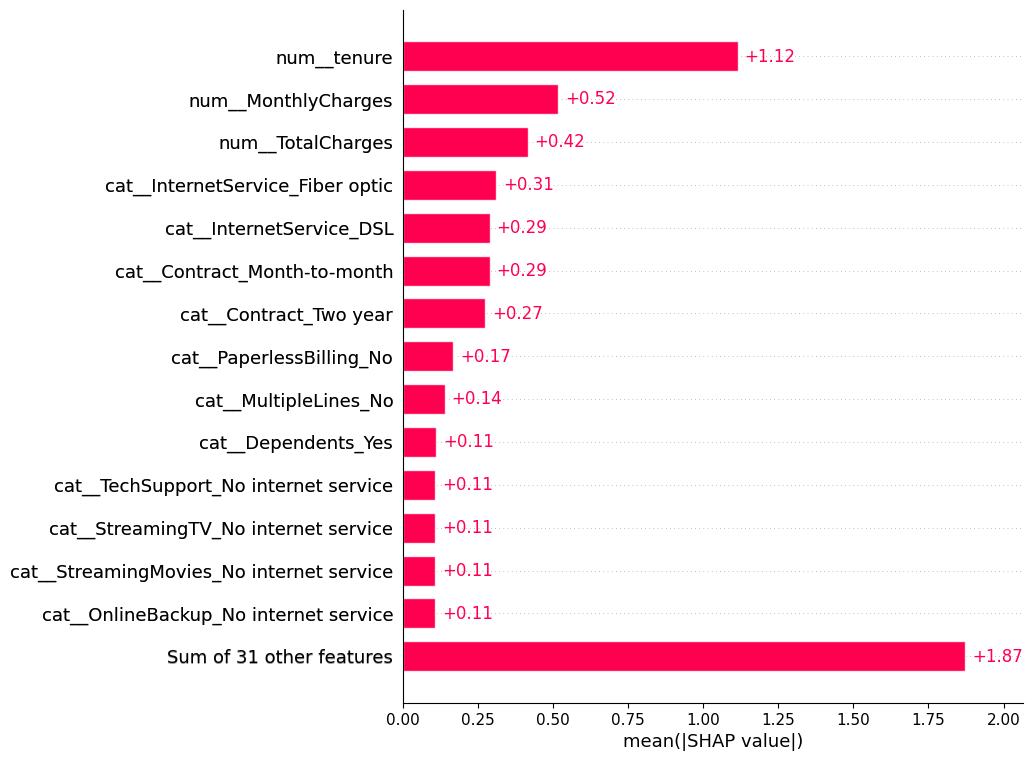

In [33]:
shap.plots.bar(shap_values, max_display=15)

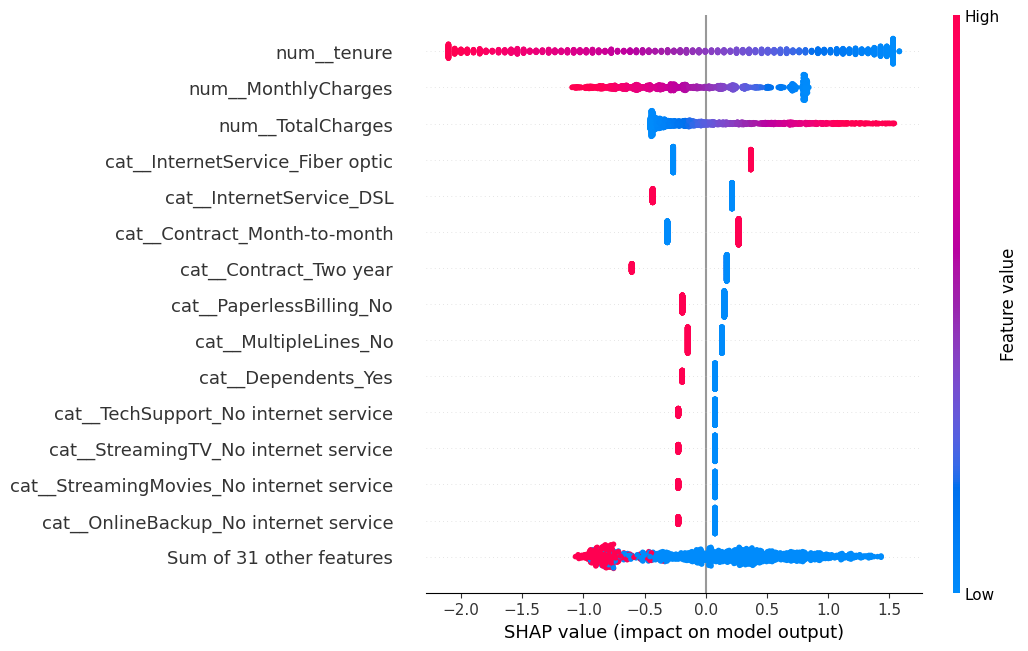

In [34]:
shap.plots.beeswarm(shap_values, max_display=15)

In [35]:
import pandas as pd

print(
    pd.DataFrame({
        "Feature": x_test_processed.columns,
        "Coefficient": model.coef_[0]
    }).sort_values(
        "Coefficient",
        ascending=False
    ).head(15)
)

                                Feature  Coefficient
12     cat__InternetService_Fiber optic     0.634195
32         cat__Contract_Month-to-month     0.582883
44                    num__TotalCharges     0.536253
31             cat__StreamingMovies_Yes     0.200938
28                 cat__StreamingTV_Yes     0.200481
39  cat__PaymentMethod_Electronic check     0.197867
14               cat__OnlineSecurity_No     0.156279
23                  cat__TechSupport_No     0.131503
10               cat__MultipleLines_Yes     0.104649
41                   num__SeniorCitizen     0.053449
17                 cat__OnlineBackup_No     0.033455
36            cat__PaperlessBilling_Yes     0.028672
22            cat__DeviceProtection_Yes     0.021983
20             cat__DeviceProtection_No    -0.036433
4                    cat__Dependents_No    -0.046067


In [36]:
contract_index = list(
    x_test_processed.columns
).index("cat__Contract_Month-to-month")

print("Coefficient:",
      model.coef_[0][contract_index])

print("Feature values:")
print(
    x_test_processed["cat__Contract_Month-to-month"].head(10)
)

print("SHAP values:")
print(
    shap_values.values[:10, contract_index]
)

Coefficient: 0.5828828386990907
Feature values:
437     0.0
2280    1.0
2235    0.0
4460    1.0
3761    0.0
5748    1.0
3568    1.0
2976    1.0
5928    0.0
1639    1.0
Name: cat__Contract_Month-to-month, dtype: float64
SHAP values:
[-0.31475673  0.26812611 -0.31475673  0.26812611 -0.31475673  0.26812611
  0.26812611  0.26812611 -0.31475673  0.26812611]


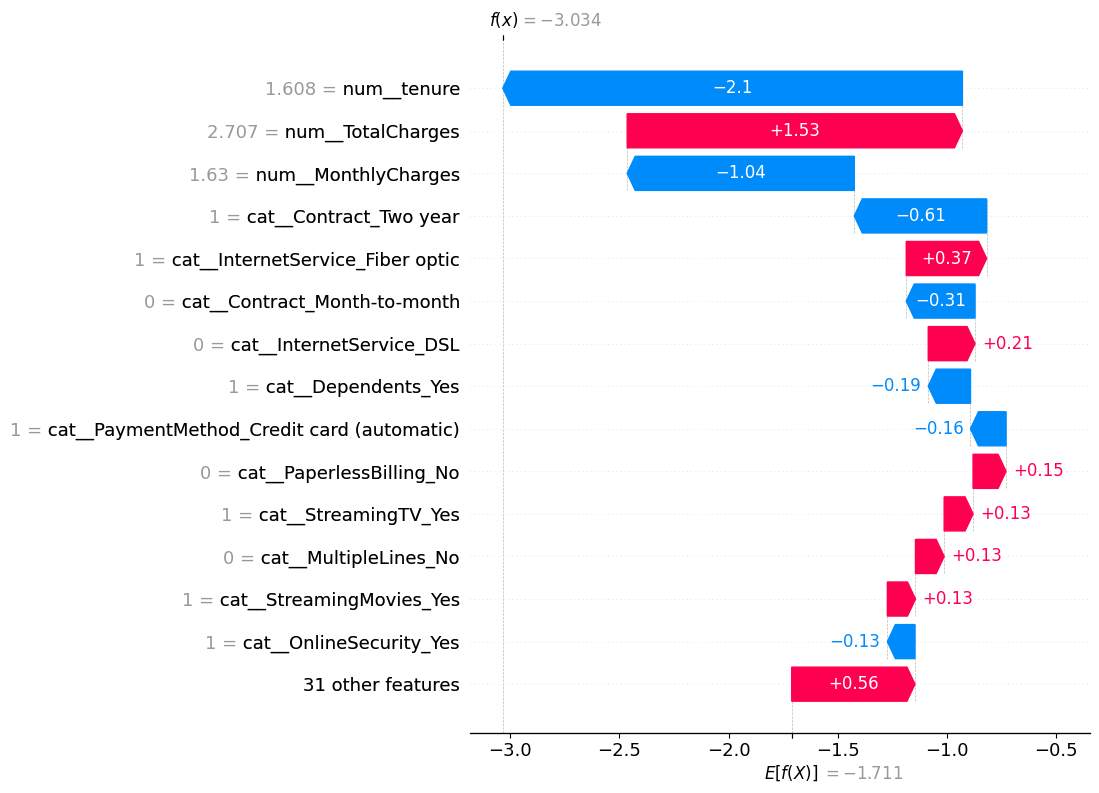

In [37]:
customer_index = 0

shap.plots.waterfall(
    shap_values[customer_index],
    max_display=15
)

## 2. SHAP Analysis Summary

SHAP was used to interpret the predictions made by the Logistic Regression
model at both global and individual levels.

The global SHAP analysis showed that features such as tenure,
MonthlyCharges, TotalCharges, InternetService, and Contract-related
features had important influences on the model's predictions.

The SHAP beeswarm plot showed both the importance and direction of
feature contributions. For example, lower tenure values generally
pushed predictions toward churn, while higher tenure values generally
pushed predictions away from churn.

The individual SHAP waterfall plot demonstrated how different features
contributed to a specific customer's prediction. Positive SHAP values
pushed the model output toward churn, while negative SHAP values pushed
it away from churn.

SHAP provides model explanations and should not be interpreted as proof
of causal relationships between features and customer churn.